✅ Data berhasil dimuat!
Contoh data 5 teratas:


,mq2,mq135,label
0,3.55,3.92,1
1,3.55,4.07,1
2,3.55,3.92,1
3,3.55,4.22,1
4,3.55,3.92,1



Jumlah total dataset: 3600 baris, 3 kolom

📊 Proporsi Pembagian Data:
Data Latih (Train) : 2880 sampel
Data Uji (Test)    : 720 sampel

⚙️ Melatih Model Regresi Logistik Biner...
✅ Model selesai dilatih!

--- Evaluasi Training ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

--- Evaluasi Testing ---
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


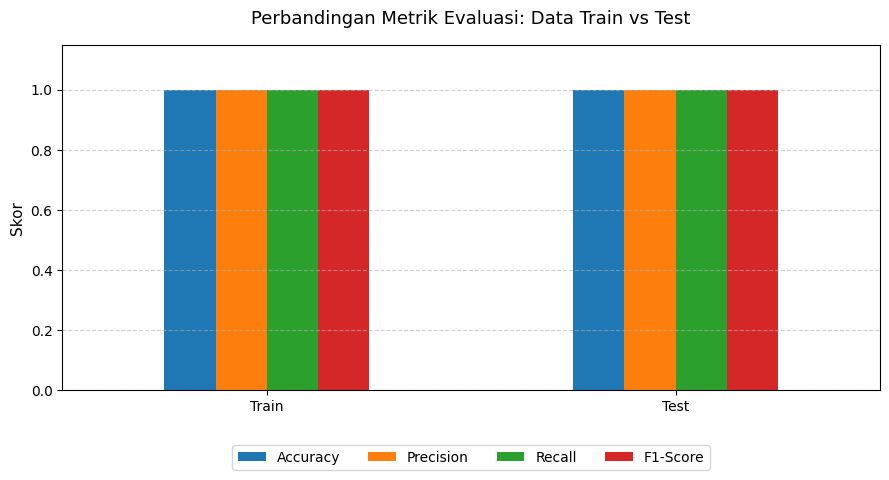

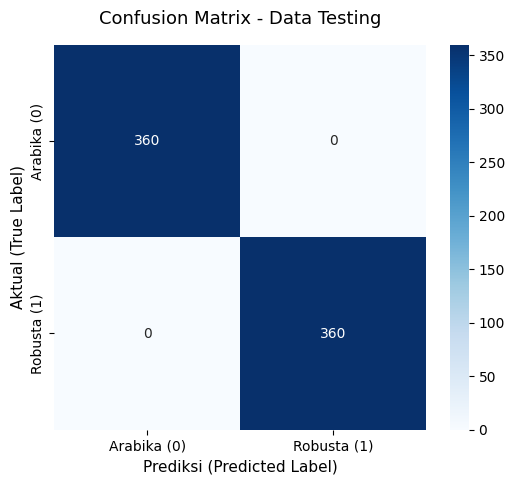

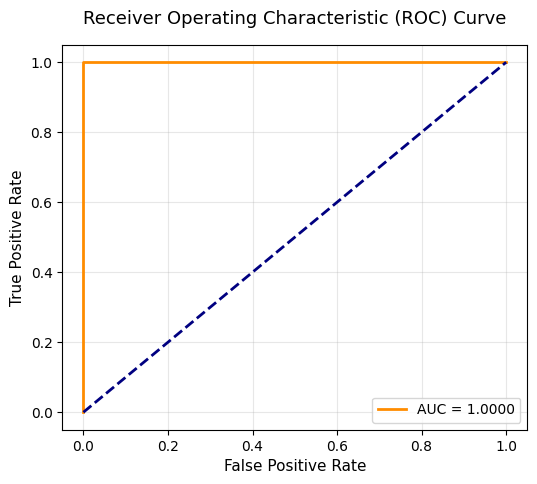

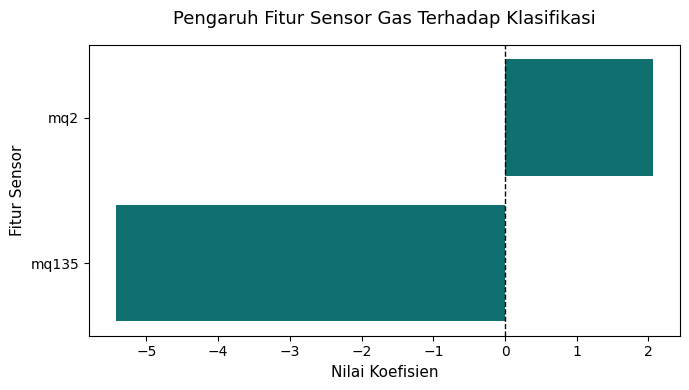


💾 Eksekusi Berhasil: Model (logreg_coffee_model.pkl) dan Scaler (scaler_coffee.pkl) telah disimpan di direktori lokal!


In [1]:
# ======================================================
# PROJECT MACHINE LEARNING
# KLASIFIKASI KOPI ARABIKA vs ROBUSTA
# METODE: REGRESI LOGISTIK BINER
# Label: 0 = Arabika, 1 = Robusta
# Split: 80% Train, 20% Test
# ======================================================

# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib # Library untuk menyimpan model machine learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

# 2. Load Dataset
# Pastikan file 'dataset_kopi.csv' diletakkan di dalam satu folder dengan notebook ini
path = 'dataset_kopi.csv' 
data = pd.read_csv(path)

print("✅ Data berhasil dimuat!")
print("Contoh data 5 teratas:")
display(data.head())
print(f"\nJumlah total dataset: {data.shape[0]} baris, {data.shape[1]} kolom")

# 3. Pisahkan Fitur (X) dan Label (y)
X = data.drop(columns=['label'])
y = data['label']

# 4. Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Memastikan proporsi kelas Arabika & Robusta seimbang di set Train & Test
)

print("\n📊 Proporsi Pembagian Data:")
print(f"Data Latih (Train) : {X_train.shape[0]} sampel")
print(f"Data Uji (Test)    : {X_test.shape[0]} sampel")

# 5. Standarisasi Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Training Model Regresi Logistik
print("\n⚙️ Melatih Model Regresi Logistik Biner...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("✅ Model selesai dilatih!")

# 7. Fungsi Evaluasi
def evaluate_model(X, y, model_obj, name):
    y_pred = model_obj.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n--- Evaluasi {name} ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# 8. Hitung Performa Model
train_metrics = evaluate_model(X_train_scaled, y_train, model, "Training")
test_metrics = evaluate_model(X_test_scaled, y_test, model, "Testing")

# 9. Visualisasi Metrik Evaluasi (Perbandingan Train vs Test)
metrics_df = pd.DataFrame(
    [train_metrics, test_metrics],
    columns=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    index=['Train', 'Test']
)

# Plot langsung menggunakan axes dari Pandas DataFrame agar tidak duplikat figure
ax = metrics_df.plot(kind='bar', figsize=(9,5), rot=0, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Perbandingan Metrik Evaluasi: Data Train vs Test', fontsize=13, pad=15)
plt.ylabel('Skor', fontsize=11)
plt.ylim(0, 1.15)
plt.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.25))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 10. Confusion Matrix (Data Test)
y_test_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Arabika (0)', 'Robusta (1)'],
            yticklabels=['Arabika (0)', 'Robusta (1)'])
plt.xlabel('Prediksi (Predicted Label)', fontsize=11)
plt.ylabel('Aktual (True Label)', fontsize=11)
plt.title('Confusion Matrix - Data Testing', fontsize=13, pad=15)
plt.show()

# 11. ROC Curve dan AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, pad=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 12. Visualisasi Pengaruh Fitur (Koefisien Regresi)
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_[0]
}).sort_values(by='Koefisien', ascending=False)

plt.figure(figsize=(7,4))
# Menghindari deprecation warning pada Seaborn versi terbaru dengan assign parameter color
sns.barplot(x='Koefisien', y='Fitur', data=coef_df, color='teal')
plt.title('Pengaruh Fitur Sensor Gas Terhadap Klasifikasi', fontsize=13, pad=15)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Nilai Koefisien', fontsize=11)
plt.ylabel('Fitur Sensor', fontsize=11)
plt.tight_layout()
plt.show()

# 13. Simpan Model & Scaler (Tahap Terakhir)
joblib.dump(model, 'logreg_coffee_model.pkl')
joblib.dump(scaler, 'scaler_coffee.pkl')
print("\n💾 Eksekusi Berhasil: Model (logreg_coffee_model.pkl) dan Scaler (scaler_coffee.pkl) telah disimpan di direktori lokal!")